## Milestone 1: Synthetic Corporate Portfolio Construction

**Objective:** Build a 500-borrower synthetic corporate loan portfolio across 5 sectors, 
with realistic default probabilities, exposure sizes, and recovery assumptions. This 
portfolio is the foundation for the Vasicek correlation model (Milestone 2) and Monte 
Carlo simulation (Milestone 3) that follow.

**Why synthetic data:** Credit VaR models are conventionally built and stress-tested on 
hypothetical portfolios with known, controllable parameters — standard practice in bank 
risk teams for validating model behavior independent of any single dataset's quirks. 
This mirrors how AIB, BOI, and EU-hub banks build internal capital models.

**Key design choice:** unlike Project 1's IFRS9 model, where each loan's default was 
treated independently, this portfolio is deliberately structured by sector — setting up 
the correlation modelling in Milestone 2, where sector becomes the channel through which 
a shared economic shock (e.g. a recession) can hit many borrowers at once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

### Sector risk parameters

Each sector is assigned a PD range and a recovery rate, chosen to reflect realistic, 
directionally accurate risk differences:
- **Real Estate & Energy:** wider, higher PD ranges — historically the most cyclical, 
  boom-bust sectors (property crashes, oil price shocks), and a key driver of the Irish 
  banking crisis (2008–2013).
- **Real Estate:** highest recovery rate (55%), reflecting physical collateral that can 
  be seized and sold.
- **Technology:** lowest recovery rate (30%), reflecting intangible assets (IP, contracts) 
  that are harder to liquidate in default.

These values are illustrative, not literal regulatory figures, but are directionally 
aligned with how Basel/IRB frameworks differentiate corporate sector risk.

In [2]:
sectors = ['Banking', 'Real Estate', 'Retail', 'Technology', 'Energy']

sector_params = {
    'Banking':      {'pd_range': (0.01, 0.04), 'recovery_rate': 0.50},
    'Real Estate':  {'pd_range': (0.03, 0.08), 'recovery_rate': 0.55},
    'Retail':       {'pd_range': (0.02, 0.06), 'recovery_rate': 0.35},
    'Technology':   {'pd_range': (0.01, 0.05), 'recovery_rate': 0.30},
    'Energy':       {'pd_range': (0.02, 0.07), 'recovery_rate': 0.45},
}

### Generating borrower-level attributes

Each of the 500 borrowers is randomly assigned a sector, then given a PD drawn uniformly 
from that sector's range — so borrowers within a sector are similarly risky but not 
identical.

In [3]:
n_borrowers = 500

borrower_sector = np.random.choice(sectors, size=n_borrowers)

In [4]:
borrower_sector

array(['Technology', 'Energy', 'Retail', 'Energy', 'Energy',
       'Real Estate', 'Retail', 'Retail', 'Retail', 'Energy',
       'Technology', 'Retail', 'Energy', 'Real Estate', 'Technology',
       'Real Estate', 'Technology', 'Energy', 'Banking', 'Technology',
       'Real Estate', 'Energy', 'Technology', 'Banking', 'Banking',
       'Retail', 'Retail', 'Real Estate', 'Technology', 'Technology',
       'Retail', 'Technology', 'Technology', 'Banking', 'Retail',
       'Energy', 'Retail', 'Energy', 'Banking', 'Real Estate',
       'Technology', 'Banking', 'Technology', 'Real Estate',
       'Real Estate', 'Banking', 'Real Estate', 'Energy', 'Real Estate',
       'Technology', 'Technology', 'Technology', 'Technology', 'Energy',
       'Retail', 'Banking', 'Technology', 'Real Estate', 'Technology',
       'Real Estate', 'Real Estate', 'Technology', 'Energy',
       'Real Estate', 'Real Estate', 'Technology', 'Real Estate',
       'Real Estate', 'Technology', 'Technology', 'Banking', 'En

In [5]:
borrower_pd = []

for sector in borrower_sector:
    pd_min, pd_max = sector_params[sector]['pd_range']
    pd_value = np.random.uniform(pd_min, pd_max)
    borrower_pd.append(pd_value)

borrower_pd = np.array(borrower_pd)

In [6]:
borrower_pd[:5]

array([0.03021009, 0.06132287, 0.03280198, 0.06477616, 0.03946008])

### Exposure sizing

Exposure amounts are drawn from a **lognormal distribution** rather than a uniform one, 
to reflect a realistic loan book: many small-to-medium exposures, with a long right tail 
of a few large ones. This skew is what makes concentration risk analysis (Milestone 5) 
meaningful — a handful of large exposures can dominate portfolio risk even when average 
PD looks moderate.

In [7]:
borrower_exposure = np.random.lognormal(mean=14, sigma=1, size=n_borrowers)

In [8]:
print(borrower_exposure[:5])
print(borrower_exposure.mean())
print(borrower_exposure.max())

[1666328.10191224  344168.42483469 3029860.14364348  999587.39073936
  713028.72027869]
2137500.958167134
16724446.426025296


### Recovery rate and LGD

Recovery rate is fixed per sector (see parameters above). LGD is derived directly: 
**LGD = 1 − Recovery Rate**, consistent with the LGD terminology used in Project 1's 
IFRS9 model.

In [9]:
borrower_recovery = np.array([sector_params[sector]['recovery_rate'] for sector in borrower_sector])

In [10]:
# This is the same thing, written the "slow" way:
borrower_recovery = []
for sector in borrower_sector:
    rate = sector_params[sector]['recovery_rate']
    borrower_recovery.append(rate)
borrower_recovery = np.array(borrower_recovery)

In [11]:

print(borrower_recovery[:5])

[0.3  0.45 0.35 0.45 0.45]


In [12]:
print(borrower_sector[:5])

['Technology' 'Energy' 'Retail' 'Energy' 'Energy']


### Assembling the portfolio table

All borrower-level attributes are combined into a single DataFrame — one row per 
borrower — which becomes the base object for every subsequent milestone.

In [13]:
portfolio = pd.DataFrame({
    'borrower_id': range(1, n_borrowers + 1),
    'sector': borrower_sector,
    'pd': borrower_pd,
    'exposure': borrower_exposure,
    'recovery_rate': borrower_recovery
})

portfolio['lgd'] = 1 - portfolio['recovery_rate']

portfolio.head()

,borrower_id,sector,pd,exposure,recovery_rate,lgd
0,1,Technology,0.030210,1.666328e+06,0.30,0.70
1,2,Energy,0.061323,3.441684e+05,0.45,0.55
2,3,Retail,0.032802,3.029860e+06,0.35,0.65
3,4,Energy,0.064776,9.995874e+05,0.45,0.55
4,5,Energy,0.039460,7.130287e+05,0.45,0.55


### Validation

Before proceeding, the portfolio is checked two ways: numerically (sector-level average 
PD should land near each range's midpoint; borrower counts should be roughly even across 
sectors) and visually (PD distribution and total exposure by sector).

**Finding:** Real Estate carries both the highest average PD and the highest total 
exposure in the portfolio — the sector most likely to generate losses is also the one 
the portfolio is most exposed to. This is the concentration risk story that Milestones 
2–5 will quantify precisely.

In [14]:
portfolio.groupby('sector').agg(
    count=('borrower_id', 'count'),
    avg_pd=('pd', 'mean'),
    avg_exposure=('exposure', 'mean'),
    total_exposure=('exposure', 'sum')
)

,count,avg_pd,avg_exposure,total_exposure
sector,,,,
Banking,109,0.023140,2.015431e+06,2.196820e+08
Energy,93,0.046834,1.794780e+06,1.669146e+08
Real Estate,95,0.055902,2.984596e+06,2.835366e+08
Retail,91,0.037571,1.819918e+06,1.656125e+08
Technology,112,0.030660,2.080400e+06,2.330048e+08


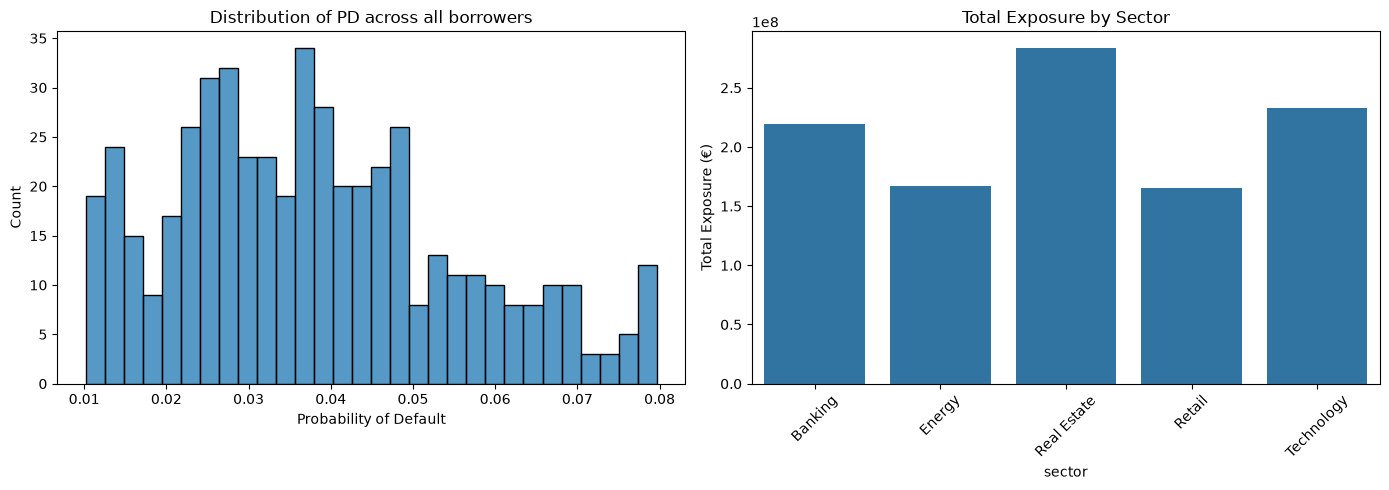

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(portfolio['pd'], bins=30, ax=axes[0])
axes[0].set_title('Distribution of PD across all borrowers')
axes[0].set_xlabel('Probability of Default')

sns.barplot(x=portfolio.groupby('sector')['exposure'].sum().index,
            y=portfolio.groupby('sector')['exposure'].sum().values,
            ax=axes[1])
axes[1].set_title('Total Exposure by Sector')
axes[1].set_ylabel('Total Exposure (€)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
portfolio.to_csv('synthetic_portfolio.csv', index=False)

## Milestone 2: Vasicek Single-Factor Model

**Objective:** Introduce default correlation into the portfolio using the Vasicek 
single-factor model — the theoretical foundation of Basel II/III IRB credit capital 
calculations. This replaces the implicit "independent defaults" assumption from 
Project 1 with a structure where borrowers' defaults are linked through a shared 
economic factor.

**Core idea:** each borrower's simulated "asset value" (a proxy for financial health) 
is split into two parts — a systematic component shared by every borrower (Z, 
representing the state of the economy) and an idiosyncratic component unique to that 
borrower (ε, firm-specific luck). A borrower defaults if their combined asset value 
falls below a threshold derived from their individual PD.

**Formula:** Asset value = √ρ × Z + √(1−ρ) × ε

Because every borrower shares the same Z within a given scenario, a bad economic draw 
pushes all borrowers' asset values down simultaneously — producing correlated, 
clustered defaults rather than independent ones. This is what allows the model to 
capture realistic recession-driven default spikes.

In [17]:
portfolio = pd.read_csv('synthetic_portfolio.csv')
portfolio.head()

,borrower_id,sector,pd,exposure,recovery_rate,lgd
0,1,Technology,0.030210,1.666328e+06,0.30,0.70
1,2,Energy,0.061323,3.441684e+05,0.45,0.55
2,3,Retail,0.032802,3.029860e+06,0.35,0.65
3,4,Energy,0.064776,9.995874e+05,0.45,0.55
4,5,Energy,0.039460,7.130287e+05,0.45,0.55


### Asset correlation (ρ) by sector

Each sector is assigned an asset correlation parameter ρ, within the Basel III / CRR 
Article 153 prescribed range for corporate exposures (12%–24%). ρ determines how much 
of a borrower's fate is driven by the broader economy (Z) versus firm-specific factors 
(ε):
- **Real Estate (0.24):** highest — most systematically exposed to macroeconomic 
  conditions, consistent with its historical cyclicality (a key driver of the Irish 
  banking crisis, 2008–2013).
- **Retail (0.12):** lowest — more driven by localized, idiosyncratic factors than 
  the macro economy.
- Other sectors sit within this range based on how macro-driven their risk profile 
  tends to be.

In [18]:
sector_rho = {
    'Banking':      0.15,
    'Real Estate':  0.24,
    'Retail':       0.12,
    'Technology':   0.14,
    'Energy':       0.20,
}

portfolio['rho'] = portfolio['sector'].map(sector_rho)
portfolio.head()

,borrower_id,sector,pd,exposure,recovery_rate,lgd,rho
0,1,Technology,0.030210,1.666328e+06,0.30,0.70,0.14
1,2,Energy,0.061323,3.441684e+05,0.45,0.55,0.20
2,3,Retail,0.032802,3.029860e+06,0.35,0.65,0.12
3,4,Energy,0.064776,9.995874e+05,0.45,0.55,0.20
4,5,Energy,0.039460,7.130287e+05,0.45,0.55,0.20


### Converting PD into a default threshold

Asset values are assumed to follow a standard normal distribution. Each borrower's PD 
is converted into a default threshold using the inverse normal function 
(`scipy.stats.norm.ppf`) — the point on the distribution below which exactly PD% of 
the probability mass sits. A borrower defaults in a given scenario if their simulated 
asset value falls below this threshold.

Higher-PD borrowers have thresholds closer to zero (easier to breach); lower-PD 
borrowers have thresholds further into the negative tail (harder to breach) — this 
threshold is simply PD expressed on the asset-value scale.

In [19]:
from scipy.stats import norm

portfolio['default_threshold'] = norm.ppf(portfolio['pd'])
portfolio.head()

,borrower_id,sector,pd,exposure,recovery_rate,lgd,rho,default_threshold
0,1,Technology,0.030210,1.666328e+06,0.30,0.70,0.14,-1.877715
1,2,Energy,0.061323,3.441684e+05,0.45,0.55,0.20,-1.543763
2,3,Retail,0.032802,3.029860e+06,0.35,0.65,0.12,-1.841120
3,4,Energy,0.064776,9.995874e+05,0.45,0.55,0.20,-1.515870
4,5,Energy,0.039460,7.130287e+05,0.45,0.55,0.20,-1.756986


In [20]:
from scipy.stats import norm
print(norm.ppf(0.05))

-1.6448536269514729


### Single-scenario test

Before scaling to a full Monte Carlo simulation (Milestone 3), a single simulated year 
is tested by hand: one systematic factor Z is drawn (shared by all borrowers), each 
borrower draws their own idiosyncratic ε, asset values are computed via the Vasicek 
formula, and defaults are flagged where asset value falls below the borrower's 
threshold.

This test confirms the mechanic works as expected: a favorable economic draw (positive 
Z) pushes asset values up across the portfolio, resulting in very few defaults, while a 
poor economic draw would be expected to push many borrowers below their thresholds 
simultaneously — the clustering behavior a single-factor model is designed to produce. 
A single simulated year cannot reveal the portfolio's true tail risk; this requires 
repeating the process thousands of times, which is the objective of Milestone 3.

In [21]:
np.random.seed(1)

Z = np.random.normal(0, 1)
print("Systematic factor Z (this simulated year):", Z)

epsilon = np.random.normal(0, 1, size=n_borrowers)

asset_value = np.sqrt(portfolio['rho']) * Z + np.sqrt(1 - portfolio['rho']) * epsilon

portfolio['defaulted'] = asset_value < portfolio['default_threshold']

print("Number of defaults this simulated year:", portfolio['defaulted'].sum())

Systematic factor Z (this simulated year): 1.6243453636632417
Number of defaults this simulated year: 1


In [22]:
np.random.seed(7)

Z = np.random.normal(0, 1)
print("Systematic factor Z (this simulated year):", Z)

epsilon = np.random.normal(0, 1, size=n_borrowers)

asset_value = np.sqrt(portfolio['rho']) * Z + np.sqrt(1 - portfolio['rho']) * epsilon

portfolio

Systematic factor Z (this simulated year): 1.690525703800356


,borrower_id,sector,pd,exposure,recovery_rate,lgd,rho,default_threshold,defaulted
0,1,Technology,0.030210,1.666328e+06,0.30,0.70,0.14,-1.877715,False
1,2,Energy,0.061323,3.441684e+05,0.45,0.55,0.20,-1.543763,False
2,3,Retail,0.032802,3.029860e+06,0.35,0.65,0.12,-1.841120,False
3,4,Energy,0.064776,9.995874e+05,0.45,0.55,0.20,-1.515870,False
4,5,Energy,0.039460,7.130287e+05,0.45,0.55,0.20,-1.756986,False
...,...,...,...,...,...,...,...,...,...
495,496,Banking,0.036890,3.167837e+05,0.50,0.50,0.15,-1.787974,False
496,497,Retail,0.020520,6.591012e+05,0.35,0.65,0.12,-2.043124,False
497,498,Banking,0.012565,1.655779e+06,0.50,0.50,0.15,-2.239391,False
498,499,Banking,0.016237,2.445087e+05,0.50,0.50,0.15,-2.138537,False


In [23]:
np.random.seed(7)

Z = np.random.normal(0, 1)
print("Systematic factor Z (this simulated year):", Z)

epsilon = np.random.normal(0, 1, size=n_borrowers)

asset_value = np.sqrt(portfolio['rho']) * Z + np.sqrt(1 - portfolio['rho']) * epsilon

portfolio['defaulted'] = asset_value < portfolio['default_threshold']

print("Number of defaults this simulated year:", portfolio['defaulted'].sum())

Systematic factor Z (this simulated year): 1.690525703800356
Number of defaults this simulated year: 3


## Milestone 3: Monte Carlo Simulation

**Objective:** Simulate 10,000 possible "years," each with its own random economic 
scenario (Z) and borrower-specific outcomes (ε), to generate a full distribution of 
possible portfolio losses — rather than a single expected value.

**Why this is necessary:** the single-year tests in Milestone 2 showed that any 
individual simulated year is dominated by noise (a nearly identical Z produced 1 default 
in one run and 3 in another). Only by repeating the experiment thousands of times does a 
stable, interpretable pattern emerge — this is the core principle of Monte Carlo 
simulation, used throughout quantitative finance for VaR, derivatives pricing, and 
stress testing.

**From default count to euro loss:** each borrower's potential loss, if they default, is 
pre-calculated as Exposure × LGD. In each simulated year, total portfolio loss is the 
sum of this value across every borrower who crossed their default threshold that year — 
borrowers who didn't default contribute zero loss.

In [24]:
n_simulations = 10000

portfolio['loss_given_default'] = portfolio['exposure'] * portfolio['lgd']
portfolio[['borrower_id', 'exposure', 'lgd', 'loss_given_default']].head()

,borrower_id,exposure,lgd,loss_given_default
0,1,1.666328e+06,0.70,1.166430e+06
1,2,3.441684e+05,0.55,1.892926e+05
2,3,3.029860e+06,0.65,1.969409e+06
3,4,9.995874e+05,0.55,5.497731e+05
4,5,7.130287e+05,0.55,3.921658e+05


### The simulation loop

For each of 10,000 simulated years: one systematic factor Z is drawn (shared across all 
borrowers), 500 idiosyncratic ε values are drawn (one per borrower), asset values are 
computed via the Vasicek formula, defaults are flagged, and total portfolio loss for 
that year is calculated and stored. The result is an array of 10,000 portfolio loss 
values — the full simulated loss distribution.

In [25]:
simulated_losses = []

for i in range(n_simulations):
    Z = np.random.normal(0, 1)
    epsilon = np.random.normal(0, 1, size=n_borrowers)
    
    asset_value = np.sqrt(portfolio['rho']) * Z + np.sqrt(1 - portfolio['rho']) * epsilon
    
    defaulted = asset_value < portfolio['default_threshold']
    
    portfolio_loss = (portfolio['loss_given_default'] * defaulted).sum()
    
    simulated_losses.append(portfolio_loss)

simulated_losses = np.array(simulated_losses)

print("Simulation complete.")
print("Number of simulated years:", len(simulated_losses))

Simulation complete.
Number of simulated years: 10000


### Validating the loss distribution

The mean simulated loss (Monte Carlo Expected Loss) is cross-checked against a simple 
back-of-envelope estimate (Total Exposure × Average PD × Average LGD) and found to be 
closely aligned — confirming that introducing default correlation does not change the 
portfolio's long-run average loss, only how that loss is distributed across scenarios 
(consistent with Vasicek theory).

The wide gap between minimum (€0) and maximum (~€208.6M) simulated losses, along with a 
standard deviation nearly as large as the mean itself, is the direct signature of 
correlated defaults — an uncorrelated portfolio would show a much narrower, more 
predictable range of outcomes.

In [26]:
print("Mean simulated loss (Expected Loss):", simulated_losses.mean())
print("Minimum simulated loss:", simulated_losses.min())
print("Maximum simulated loss:", simulated_losses.max())
print("Standard deviation of losses:", simulated_losses.std())

Mean simulated loss (Expected Loss): 22801165.42243537
Minimum simulated loss: 0.0
Maximum simulated loss: 208642681.4527864
Standard deviation of losses: 23448352.019111622


### The loss distribution is right-skewed

The histogram of 10,000 simulated losses shows a classic right-skewed credit loss shape: 
most years cluster at low losses, while a long thin tail extends toward severe, 
correlated-default scenarios. Notably, the mean (Expected Loss) sits to the right of the 
distribution's peak — the most common outcome is actually below average, with a small 
number of extreme-loss years pulling the mean upward.

This is the central motivation for Credit VaR: Expected Loss alone understates the 
capital a bank needs to hold, since it does not account for the tail risk visible in 
this distribution. Milestone 4 quantifies that tail risk directly.

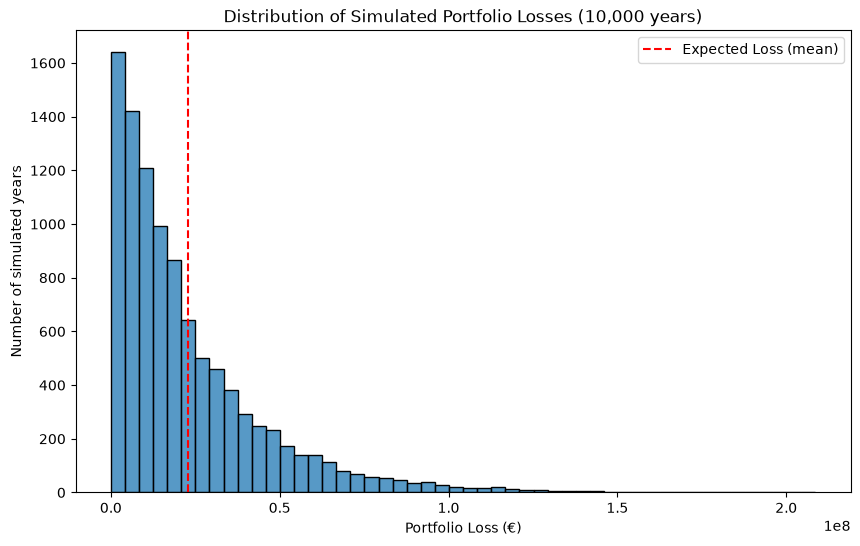

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(simulated_losses, bins=50)
plt.axvline(simulated_losses.mean(), color='red', linestyle='--', label='Expected Loss (mean)')
plt.title('Distribution of Simulated Portfolio Losses (10,000 years)')
plt.xlabel('Portfolio Loss (€)')
plt.ylabel('Number of simulated years')
plt.legend()
plt.show()

## Milestone 4: Credit VaR and Expected Shortfall

**Objective:** Convert the 10,000-year simulated loss distribution into the formal risk 
metrics used in bank capital calculations: Expected Loss, Credit VaR, Expected Shortfall, 
and Unexpected Loss.

**Expected Loss (EL):** the mean of the simulated loss distribution — conceptually 
equivalent to Project 1's ECL, now derived via simulation.

**Credit VaR:** the loss level exceeded in only 1% (or 0.1%) of simulated years, 
calculated as the 99th (or 99.9th) percentile of the loss distribution. Answers: "what 
loss are we X% confident we won't exceed?" 99.9% VaR is the Basel IRB regulatory standard.

In [28]:
expected_loss = simulated_losses.mean()

var_99 = np.percentile(simulated_losses, 99)
var_999 = np.percentile(simulated_losses, 99.9)

print("Expected Loss (EL):", expected_loss)
print("Credit VaR at 99%:", var_99)
print("Credit VaR at 99.9%:", var_999)

Expected Loss (EL): 22801165.42243537
Credit VaR at 99%: 109879159.4109318
Credit VaR at 99.9%: 168424716.15720165


### Expected Shortfall (ES)

VaR identifies a threshold but says nothing about severity beyond it. Expected Shortfall 
addresses this by averaging only the simulated losses that exceed the VaR threshold — 
answering "given we're in the worst 1% of years, what loss should we expect on average?" 
ES is considered a more complete tail-risk measure than VaR alone.

In [29]:
tail_losses_99 = simulated_losses[simulated_losses >= var_99]

expected_shortfall_99 = tail_losses_99.mean()

print("Number of years in the tail (99% ES):", len(tail_losses_99))
print("Expected Shortfall at 99%:", expected_shortfall_99)

Number of years in the tail (99% ES): 100
Expected Shortfall at 99%: 133143055.94105679


### Unexpected Loss (UL) and regulatory capital

Unexpected Loss = Credit VaR − Expected Loss. This represents the capital buffer a bank 
must hold beyond its ECL provisions, sized to survive a severe-but-plausible tail 
scenario at a given confidence level. 

**Result:** this portfolio's Expected Loss (€23.3M) is provisioned through ECL, but 
Unexpected Loss at 99.9% confidence (€145.7M) — roughly 6.3x the ECL amount — 
illustrates why expected-loss provisioning alone is insufficient for bank solvency, and 
why regulatory capital frameworks (Basel II/III) require this additional buffer.

In [30]:
unexpected_loss_99 = var_99 - expected_loss
unexpected_loss_999 = var_999 - expected_loss

print("Unexpected Loss at 99%:", unexpected_loss_99)
print("Unexpected Loss at 99.9%:", unexpected_loss_999)

Unexpected Loss at 99%: 87077993.98849642
Unexpected Loss at 99.9%: 145623550.73476627


## Milestone 5A: Sector Concentration Analysis

**Objective:** Quantify how increasing exposure concentration in a single sector affects 
tail risk (VaR, ES, UL), holding total portfolio size and every borrower's individual PD, 
ρ, and LGD constant.

**Method:** Real Estate's exposure share is scaled up to 80% of the total portfolio 
(redistributing the remainder proportionally across other sectors), and the full Monte 
Carlo simulation is re-run on this concentrated portfolio using identical logic to 
Milestone 3.

**Result:** Expected Loss rose by only 14.4% (driven by Real Estate's higher average PD), 
while Credit VaR (99%), Expected Shortfall (99%), and Unexpected Loss all rose by 35–40% — 
a substantially larger increase than EL alone would suggest.

**Interpretation:** this gap is the signature of concentration risk. It is not primarily 
that Real Estate borrowers are individually riskier — it is that concentrating exposure 
in a single sector means a much larger share of the portfolio depends on the same 
systematic factor (ρ = 0.24). When that factor draws a bad value, losses across the 
concentrated portfolio move together far more severely than in a diversified book, where 
a bad sector-specific year can be partially offset by unrelated sectors performing 
normally. This demonstrates why concentration risk must be modelled explicitly — average 
PD alone does not capture it.

In [31]:
concentrated_portfolio = portfolio.copy()

target_re_share = 0.80
current_total_exposure = concentrated_portfolio['exposure'].sum()
current_re_exposure = concentrated_portfolio.loc[concentrated_portfolio['sector'] == 'Real Estate', 'exposure'].sum()
current_other_exposure = current_total_exposure - current_re_exposure

re_scale = (target_re_share * current_total_exposure) / current_re_exposure
other_scale = ((1 - target_re_share) * current_total_exposure) / current_other_exposure

concentrated_portfolio.loc[concentrated_portfolio['sector'] == 'Real Estate', 'exposure'] *= re_scale
concentrated_portfolio.loc[concentrated_portfolio['sector'] != 'Real Estate', 'exposure'] *= other_scale

concentrated_portfolio['loss_given_default'] = concentrated_portfolio['exposure'] * concentrated_portfolio['lgd']

print("New Real Estate share of exposure:", 
      concentrated_portfolio.loc[concentrated_portfolio['sector']=='Real Estate','exposure'].sum() / concentrated_portfolio['exposure'].sum())
print("Total portfolio exposure unchanged:", concentrated_portfolio['exposure'].sum(), "vs original", current_total_exposure)

New Real Estate share of exposure: 0.8000000000000002
Total portfolio exposure unchanged: 1068750479.0835667 vs original 1068750479.0835669


In [32]:
simulated_losses_concentrated = []

for i in range(n_simulations):
    Z = np.random.normal(0, 1)
    epsilon = np.random.normal(0, 1, size=n_borrowers)
    asset_value = np.sqrt(concentrated_portfolio['rho']) * Z + np.sqrt(1 - concentrated_portfolio['rho']) * epsilon
    defaulted = asset_value < concentrated_portfolio['default_threshold']
    portfolio_loss = (concentrated_portfolio['loss_given_default'] * defaulted).sum()
    simulated_losses_concentrated.append(portfolio_loss)

simulated_losses_concentrated = np.array(simulated_losses_concentrated)

In [33]:
comparison = pd.DataFrame({
    'Diversified (baseline)': [
        expected_loss, var_99, expected_shortfall_99, unexpected_loss_99
    ],
    'Concentrated (80% RE)': [
        simulated_losses_concentrated.mean(),
        np.percentile(simulated_losses_concentrated, 99),
        simulated_losses_concentrated[simulated_losses_concentrated >= np.percentile(simulated_losses_concentrated, 99)].mean(),
        np.percentile(simulated_losses_concentrated, 99) - simulated_losses_concentrated.mean()
    ]
}, index=['Expected Loss', 'VaR 99%', 'Expected Shortfall 99%', 'Unexpected Loss 99%'])

comparison

,Diversified (baseline),Concentrated (80% RE)
Expected Loss,2.280117e+07,2.607897e+07
VaR 99%,1.098792e+08,1.482890e+08
Expected Shortfall 99%,1.331431e+08,1.797759e+08
Unexpected Loss 99%,8.707799e+07,1.222100e+08


## Milestone 5B: Stress Testing

**Objective:** Quantify portfolio loss under a single, deliberately severe economic 
scenario (Z = −3, representing an extreme, once-in-hundreds-of-years shock), as opposed 
to Credit VaR's probability-weighted tail measures. This mirrors regulatory stress 
testing frameworks (e.g. ECB, EBA adverse macro scenarios) used by Irish and EU banks.

**Method:** the systematic factor Z is fixed rather than randomly drawn; idiosyncratic 
factors (ε) remain random per borrower. The same asset-value and default-threshold logic 
from Milestone 2 is applied once under this fixed scenario.

**Result:** 138 of 500 borrowers (27.6%) defaulted under this single severe scenario, 
versus an average baseline PD of ~4% — driving a total portfolio loss of €161.4M, 
approximately 7.1x the baseline Expected Loss.

**Sector breakdown confirms the ρ mechanism directly:** default rates under stress rank 
almost exactly by sector ρ — Real Estate (ρ = 0.24) saw a 46.3% default rate, over 8x its 
baseline average PD, while lower-ρ sectors like Retail and Technology saw proportionally 
smaller amplification. This demonstrates that asset correlation (ρ) does not just 
determine *average* risk — it determines how severely a sector's defaults amplify under 
a systematic shock, which is precisely the mechanism regulatory capital frameworks are 
designed to capture and that average-PD-based approaches cannot detect.

In [34]:
Z_stress = -3.0

epsilon_stress = np.random.normal(0, 1, size=n_borrowers)

asset_value_stress = np.sqrt(portfolio['rho']) * Z_stress + np.sqrt(1 - portfolio['rho']) * epsilon_stress

portfolio['defaulted_stress'] = asset_value_stress < portfolio['default_threshold']

stress_loss = (portfolio['loss_given_default'] * portfolio['defaulted_stress']).sum()

print("Stress scenario Z:", Z_stress)
print("Number of defaults under stress:", portfolio['defaulted_stress'].sum())
print("Total portfolio loss under stress:", stress_loss)
print("Stress loss vs Expected Loss (baseline):", stress_loss / expected_loss, "x")

Stress scenario Z: -3.0
Number of defaults under stress: 138
Total portfolio loss under stress: 161361363.17205116
Stress loss vs Expected Loss (baseline): 7.076891035283595 x


In [35]:
stress_by_sector = portfolio.groupby('sector').agg(
    borrowers=('borrower_id', 'count'),
    defaults=('defaulted_stress', 'sum'),
    default_rate=('defaulted_stress', 'mean'),
    sector_loss=('loss_given_default', lambda x: (x * portfolio.loc[x.index, 'defaulted_stress']).sum())
).sort_values('default_rate', ascending=False)

stress_by_sector

,borrowers,defaults,default_rate,sector_loss
sector,,,,
Real Estate,95,44,0.463158,5.761121e+07
Energy,93,35,0.376344,3.960397e+07
Retail,91,20,0.219780,2.164615e+07
Banking,109,20,0.183486,1.529201e+07
Technology,112,19,0.169643,2.720803e+07
